In [22]:
#importe las siguentes librerias de numpy pandas  matplotlib opencv  y pillow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image



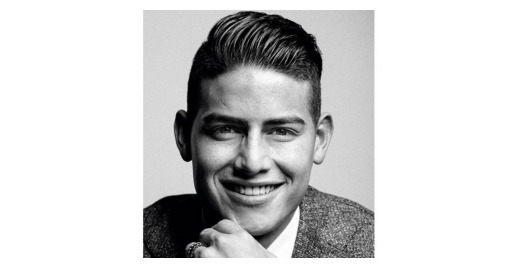

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import requests
from io import BytesIO

# URL de la imagen
url = "https://imagenes2.eltiempo.com/files/image_1200_600/uploads/2019/02/22/5c705c61605df.jpeg"

# Leer la imagen utilizando requests y Pillow
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen para confirmar que cargó correctamente
plt.imshow(img)
plt.axis('off') # Ocultar los ejes
plt.show()

In [24]:
# Convertir la imagen de Pillow a un arreglo de NumPy
img_array = np.array(img)

# Imprimir el arreglo
print("Arreglo de la imagen:")
print(img_array)

# Ver las dimensiones del arreglo (Alto, Ancho, Canales)
print(f"\nDimensiones de la matriz: {img_array.shape}")

Arreglo de la imagen:
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]

Dimensiones de la matriz: (600, 1200, 3)


Dimensiones de la imagen recortada: (600, 500, 3)


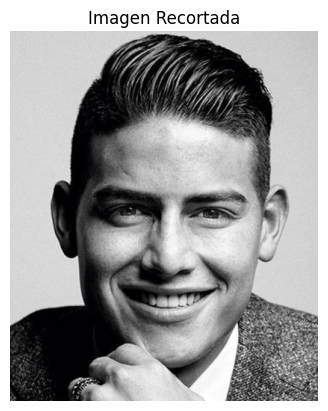

In [25]:
# Convertimos la imagen a un arreglo de numpy (si no lo has hecho)
img_array = np.array(img)

# Extraer el recorte: 
# Desde la fila 0 a la 330
# Desde la columna 600 a la 830
img_recortada = img_array[0:600, 330:830]

# Verificamos las dimensiones del recorte
print(f"Dimensiones de la imagen recortada: {img_recortada.shape}")

# Mostrar el resultado
plt.imshow(img_recortada)
plt.title("Imagen Recortada")
plt.axis('off')
plt.show()


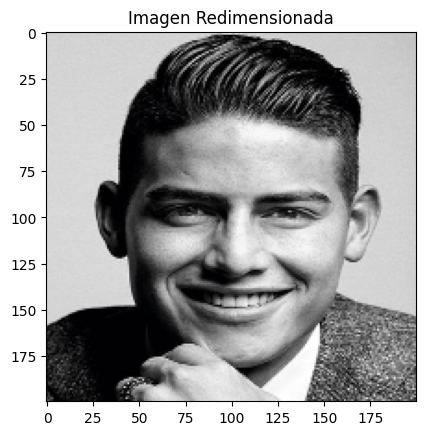

Dimensiones de la imagen redimensionada: (200, 200, 3)


In [26]:
# la imagen recortada disminuyala a 200x200 píxeles  ponga el axys on y muestre el shape
# Redimensionar la imagen recortada a 200x200 píxeles
img_redimensionada = cv2.resize(img_recortada, (200, 200))
# Mostrar la imagen redimensionada
plt.imshow(img_redimensionada)
plt.title("Imagen Redimensionada")
plt.axis('on')  # Mostrar los ejes
plt.show()
# Mostrar las dimensiones de la imagen redimensionada
print(f"Dimensiones de la imagen redimensionada: {img_redimensionada.shape}")

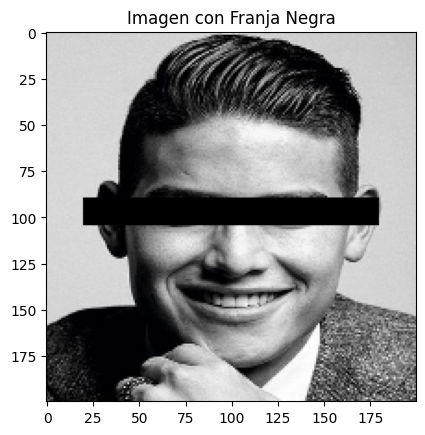

Dimensiones de la imagen con franja: (200, 200, 3)


In [27]:
# Definir la ubicación y el tamaño de la franja (en píxeles)
# NOTA: Estas coordenadas son aproximadas. Quizás necesites ajustarlas
# dependiendo de dónde estén los ojos en tu recorte original.
# Formato: img[fila_inicio:fila_fin, columna_inicio:columna_fin]
fila_inicio = 90
fila_fin = 105
columna_inicio = 20    # Empezar cerca del borde izquierdo
columna_fin = 180      # Terminar cerca del borde derecho

# Asignar el valor negro (0) a esa sección para todos los canales de color
# El negro se representa como [0, 0, 0] para RGB
img_con_franja = img_redimensionada.copy() # Hacemos una copia para no alterar la original
img_con_franja[fila_inicio:fila_fin, columna_inicio:columna_fin] = [0, 0, 0]

# --- FIN DEL NUEVO CÓDIGO ---

# Mostrar la imagen resultante
plt.imshow(img_con_franja)
plt.title("Imagen con Franja Negra")
plt.axis('on')  # Mostrar los ejes (píxeles)
plt.show()

# Verificamos que las dimensiones sigan siendo las mismas
print(f"Dimensiones de la imagen con franja: {img_con_franja.shape}")

# Procesamiento de imágenes a color

## Operaciones con las capas del arreglo a colores

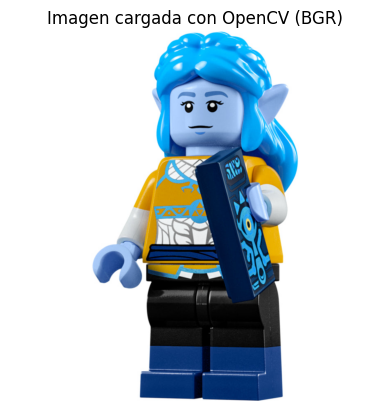

Dimensiones: (904, 904, 3) dtype: uint8


In [30]:
# Cargar la imagen con OpenCV desde la URL (sin convertir a RGB)
resp = requests.get(url2)
img_data = np.frombuffer(resp.content, dtype=np.uint8)
img_bgr_from_url = cv2.imdecode(img_data, cv2.IMREAD_COLOR)

# Mostrar con matplotlib directamente (queda en BGR)
plt.imshow(img_bgr_from_url)
plt.axis("off")
plt.title("Imagen cargada con OpenCV (BGR)")
plt.show()

print("Dimensiones:", img_bgr_from_url.shape, "dtype:", img_bgr_from_url.dtype)

Forma de la imagen RGB: (904, 904, 3)


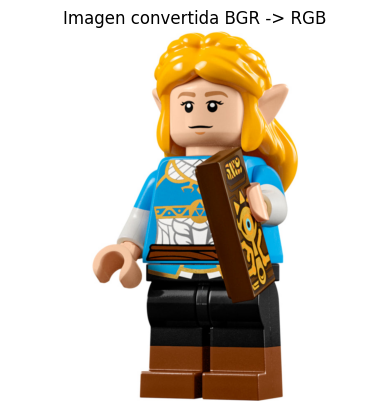

In [32]:
# Leer la imagen desde URL con requests + OpenCV
resp = requests.get(url2)
img_data = np.frombuffer(resp.content, dtype=np.uint8)
img_bgr = cv2.imdecode(img_data, cv2.IMREAD_COLOR)

# Convertir de BGR a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar la forma
print("Forma de la imagen RGB:", img_rgb.shape)

# Mostrar imagen
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Imagen convertida BGR -> RGB")
plt.show()

Shape de la imagen en escala de grises: (904, 904)


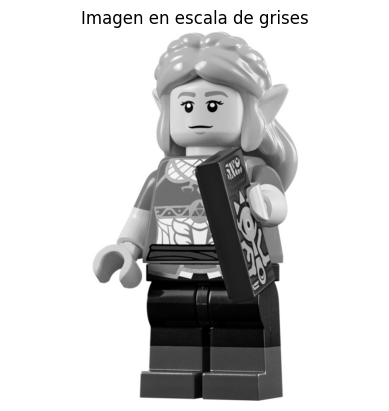

In [33]:
# Convertir img_rgb a escala de grises
img_gris = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Mostrar shape
print("Shape de la imagen en escala de grises:", img_gris.shape)

# Mostrar imagen en escala de grises
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.title("Imagen en escala de grises")
plt.show()

Shape capa0: (904, 904)


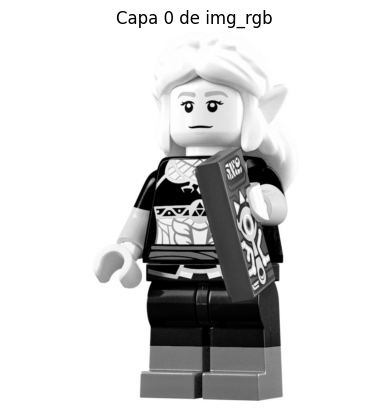

In [34]:
# Seleccionar la capa 0 (canal R en img_rgb) de la imagen
capa0 = img_rgb[:, :, 0]

# Mostrar shape y la imagen en escala de grises de esa capa
print("Shape capa0:", capa0.shape)

plt.imshow(capa0, cmap='gray')
plt.axis('off')
plt.title("Capa 0 de img_rgb")
plt.show()

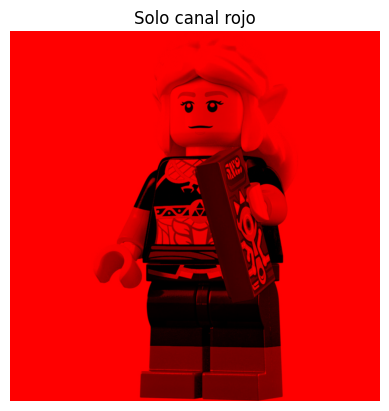

Shape: (904, 904, 3) dtype: uint8


In [35]:
# Mantener solo la capa roja en img_rgb y poner verde/azul en cero
img_rojo = img_rgb.copy()
img_rojo[:, :, 1] = 0  # canal G
img_rojo[:, :, 2] = 0  # canal B

plt.imshow(img_rojo)
plt.axis('off')
plt.title('Solo canal rojo')
plt.show()

print("Shape:", img_rojo.shape, "dtype:", img_rojo.dtype)

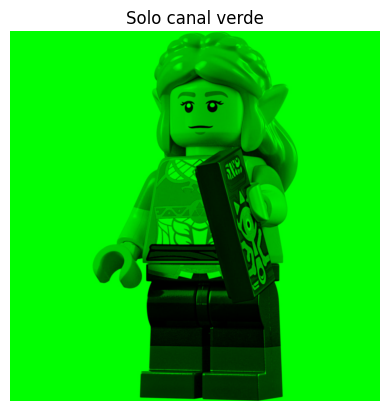

Shape: (904, 904, 3) dtype: uint8


In [36]:
# Mantener solo la capa verde en img_rgb (G) y poner rojo/azul en cero
img_verde = img_rgb.copy()
img_verde[:, :, 0] = 0  # canal R
img_verde[:, :, 2] = 0  # canal B

plt.imshow(img_verde)
plt.axis('off')
plt.title('Solo canal verde')
plt.show()

print("Shape:", img_verde.shape, "dtype:", img_verde.dtype)

# observacion
 **una convolucion es tomar una matriz y multiplicarla pr una mas grande**

**Un kernel es una matriz pequeña que generalmente es impar, solo puede tomar valores entre -6 y 6**

